# Module 2 — Base + Hand Basics
**Topics:** FK · IK · Reachability workspace · Velocity · Angular momentum · Force sensor

Base stays fixed. We explore the 3-DOF KUKA arm fully.

## 0. Imports

In [1]:
import importlib, sys

# Remove any cached env/utils modules from this session
to_remove = [key for key in sys.modules if key.startswith('env') or key.startswith('utils')]
for key in to_remove:
    del sys.modules[key]

print("Cache cleared:", to_remove)

Cache cleared: []


In [2]:
import sys
print(sys.executable)
# Must show: .../envs/reachbot/bin/python

/opt/anaconda3/envs/reachbot/bin/python


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pybullet as p

from env.pybullet_env import PyBulletEnv
from env.robot_loader import RobotLoader
from utils.kinematics import (fk, fk_all_links, ik, ik_multi_start,
                               jacobian, ee_velocity, joint_torques_from_force,
                               sample_workspace, JOINT_LIMITS)
from utils.controllers import ArmController, GripperController
from utils.sensors     import ForceSensor
from utils.visualizer  import DebugVisualizer

print('Imports OK')

Imports OK


pybullet build time: Oct 21 2025 17:40:50


## 1. Start environment

In [4]:
env    = PyBulletEnv(gui=True)
env.start()
env.set_real_time(False) 
loader = RobotLoader()
loader.load()
arm   = ArmController(loader)
grip  = GripperController(loader)
force = ForceSensor(loader)
viz   = DebugVisualizer()
env.step_n(60)
print('Robot loaded')
print('Joint map:', list(loader.joint_map.keys()))

Robot loaded
Joint map: ['joint1', 'joint2', 'joint3', 'finger_left_joint', 'finger_right_joint']


## 2. Forward Kinematics

In [5]:
configs = {
    'Home'         : np.array([ 0.0, -0.4,  0.6]),
    'Reach forward': np.array([ 0.0,  0.6,  0.0]),
    'Reach left'   : np.array([ 1.57, 0.4,  0.2]),
    'Reach right'  : np.array([-1.57, 0.4,  0.2]),
    'Elbow up'     : np.array([ 0.0, -0.8,  1.2]),
}

print(f'{"Config":<16}  {"EE pos (x,y,z)":>32}  {"Reach":>8}')
print('-'*62)
for name, q in configs.items():
    pos, _ = fk(q)
    print(f'{name:<16}  {str(pos.round(4)):>32}  {np.linalg.norm(pos):>8.4f}')

Config                              EE pos (x,y,z)     Reach
--------------------------------------------------------------
Home                     [-0.0617  0.      0.6079]    0.6110
Reach forward               [0.2259 0.     0.5601]    0.6040
Reach left         [1.000e-04 1.838e-01 5.831e-01]    0.6114
Reach right       [ 1.000e-04 -1.838e-01  5.831e-01]    0.6114
Elbow up                 [-0.1099  0.      0.5446]    0.5555


In [6]:
# Move robot through configs and draw skeleton
bp, bo = p.getBasePositionAndOrientation(loader.arm_id)
R_base = np.array(p.getMatrixFromQuaternion(bo)).reshape(3,3)

for name, q in configs.items():
    arm.move_to(q, env=env, steps=80)
    links = fk_all_links(q)
    for i in range(len(links)-1):
        p0w = np.array(bp) + R_base @ links[i][0]
        p1w = np.array(bp) + R_base @ links[i+1][0]
        p.addUserDebugLine(p0w.tolist(), p1w.tolist(), [1,0.5,0], 3, lifeTime=1.5)
    env.step_n(60)
    print(f'{name}: EE={fk(q)[0].round(3)}')

print('FK sweep done')

Home: EE=[-0.062  0.     0.608]
Reach forward: EE=[0.226 0.    0.56 ]
Reach left: EE=[0.    0.184 0.583]
Reach right: EE=[ 0.    -0.184  0.583]
Elbow up: EE=[-0.11   0.     0.545]
FK sweep done


## 3. Inverse Kinematics

In [7]:
targets = [
    np.array([ 0.00,  0.25, 0.40]),   # was already working
    np.array([ 0.20, -0.20, 0.30]),   # was already working  
    np.array([ 0.30,  0.10, 0.20]),   # was already working
    np.array([ 0.15,  0.10, 0.50]),   # new — upper hemisphere
]

print(f'{"Target":>28}  {"q solution":>34}  {"Err(mm)":>8}  OK')
print('-' * 80)
for t in targets:
    q, err = ik_multi_start(t, n_tries=20, max_iter=500, tol=1e-4)
    ok     = '✓' if err < 0.005 else '✗'
    q_str  = str(q.round(3)) if q is not None else 'None'
    print(f'{str(t.round(3)):>28}  {q_str:>34}  {err*1000:>8.2f}  {ok}')

                      Target                          q solution   Err(mm)  OK
--------------------------------------------------------------------------------
            [0.   0.25 0.4 ]              [-1.571 -0.419 -1.464]      0.08  ✓
            [ 0.2 -0.2  0.3]              [ 2.356 -0.747 -1.549]      0.07  ✓
               [0.3 0.1 0.2]                 [0.322 1.153 1.339]      0.05  ✓
            [0.15 0.1  0.5 ]              [-2.553 -0.097 -1.278]      0.06  ✓


In [8]:
# Drive arm to each IK solution
bp, bo = p.getBasePositionAndOrientation(loader.arm_id)
R_base = np.array(p.getMatrixFromQuaternion(bo)).reshape(3,3)

for t in targets:
    q, err = ik_multi_start(t, n_tries=10)
    if q is not None and err < 0.03:
        tw = np.array(bp) + R_base @ t
        viz.draw_target(tw, color=(1,0,1), radius=0.025)
        arm.move_to(q, env=env, steps=120)
        env.step_n(40)
        ee_w, _ = loader.get_ee_pose()
        print(f'Target {t.round(2)}  world EE err={np.linalg.norm(ee_w-tw)*1000:.1f} mm')

print('IK demo done')

Target [0.   0.25 0.4 ]  world EE err=6.4 mm
Target [ 0.2 -0.2  0.3]  world EE err=6.3 mm
Target [0.3 0.1 0.2]  world EE err=8.5 mm
Target [0.15 0.1  0.5 ]  world EE err=3.9 mm
IK demo done


## 4. Reachability Workspace

In [9]:
print('Sampling 5000 configs ...')
pts = sample_workspace(5000)
print(f'X [{pts[:,0].min():.3f}, {pts[:,0].max():.3f}]  '
      f'Y [{pts[:,1].min():.3f}, {pts[:,1].max():.3f}]  '
      f'Z [{pts[:,2].min():.3f}, {pts[:,2].max():.3f}]  '
      f'Max reach {np.linalg.norm(pts,axis=1).max():.3f} m')

Sampling 5000 configs ...
X [-0.395, 0.400]  Y [-0.396, 0.397]  Z [0.071, 0.630]  Max reach 0.630 m


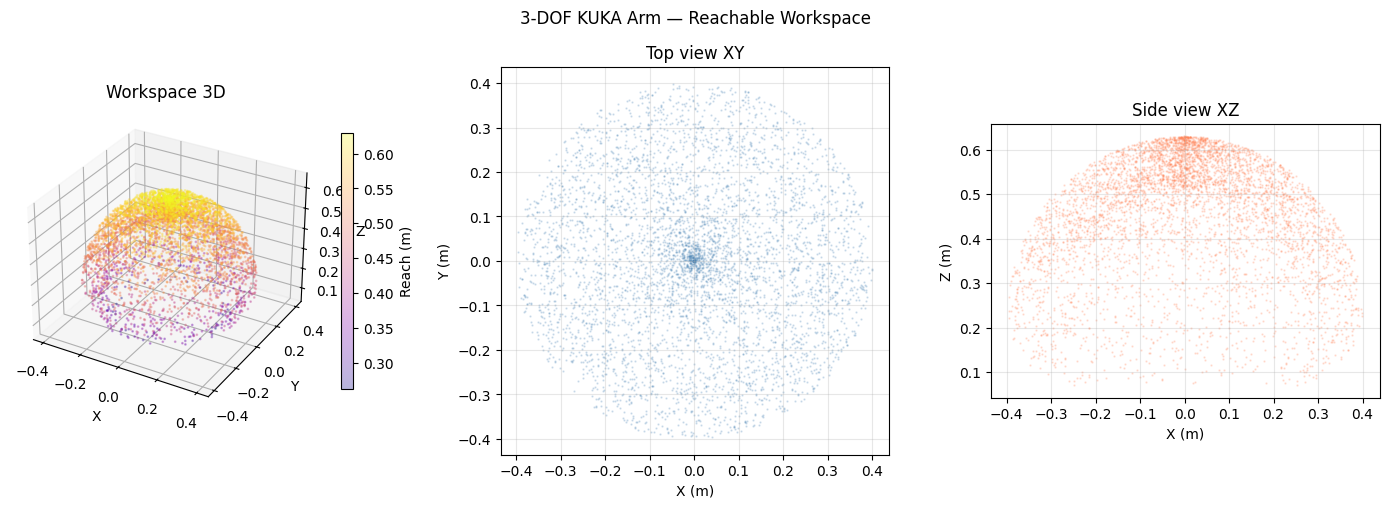

In [10]:
fig = plt.figure(figsize=(14,5))

ax1 = fig.add_subplot(131, projection='3d')
sc  = ax1.scatter(pts[:,0],pts[:,1],pts[:,2],
                  c=np.linalg.norm(pts,axis=1), cmap='plasma', s=1, alpha=0.3)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title('Workspace 3D')
plt.colorbar(sc, ax=ax1, shrink=0.6, label='Reach (m)')

ax2 = fig.add_subplot(132)
ax2.scatter(pts[:,0],pts[:,1],s=0.5,alpha=0.2,c='steelblue')
ax2.set_aspect('equal'); ax2.grid(alpha=0.3)
ax2.set_xlabel('X (m)'); ax2.set_ylabel('Y (m)'); ax2.set_title('Top view XY')

ax3 = fig.add_subplot(133)
ax3.scatter(pts[:,0],pts[:,2],s=0.5,alpha=0.2,c='coral')
ax3.set_aspect('equal'); ax3.grid(alpha=0.3)
ax3.set_xlabel('X (m)'); ax3.set_ylabel('Z (m)'); ax3.set_title('Side view XZ')

plt.suptitle('3-DOF KUKA Arm — Reachable Workspace')
plt.tight_layout(); plt.show()

## 5. Reachability check function

In [11]:
def check_reachable(target, tol=0.01):
    q, err = ik_multi_start(target, n_tries=8)
    return err < tol, q, err

test_pts = [
    ('Confirmed reach',  np.array([ 0.00,  0.25, 0.40])),  # ✓ left
    ('Confirmed reach',  np.array([ 0.15,  0.10, 0.50])),  # ✓ upper
    ('Max reach limit',  np.array([ 0.40,  0.00, 0.45])),  # boundary
    ('Below base',       np.array([ 0.10,  0.00,-0.10])),  # ✗ impossible
    ('Behind (j1=180°)', np.array([-0.30,  0.00, 0.50])),  # ✓ behind
]

print(f'{"Name":<20} {"Target":>26}  {"Reachable":>10}  {"Err(mm)":>10}')
print('-' * 72)
for name, t in test_pts:
    ok, _, err = check_reachable(t)
    print(f'{name:<20} {str(t):>26}  '
          f'{"YES ✓" if ok else "NO  ✗":>10}  {err*1000:>10.2f}')

Name                                     Target   Reachable     Err(mm)
------------------------------------------------------------------------
Confirmed reach                [0.   0.25 0.4 ]       YES ✓        0.09
Confirmed reach                [0.15 0.1  0.5 ]       YES ✓        0.08
Max reach limit                [0.4  0.   0.45]       NO  ✗       57.53
Below base                     [ 0.1  0.  -0.1]       NO  ✗      509.61
Behind (j1=180°)               [-0.3  0.   0.5]       YES ✓        3.61


## 6. Jacobian, EE Velocity & Angular Momentum

In [12]:
q    = np.array([0.3, 0.5, -0.4])
qdot = np.array([0.1, 0.2, -0.15])

J = jacobian(q)
v = ee_velocity(q, qdot)

print('q    :', q)
print('qdot :', qdot)
print('\nJacobian J (3x3):\n', J.round(4))
print('\nEE velocity v = J·qdot (m/s):', v.round(4))
print('EE speed (m/s)              :', np.linalg.norm(v).round(4))

q    : [ 0.3  0.5 -0.4]
qdot : [ 0.1   0.2  -0.15]

Jacobian J (3x3):
 [[-0.0387  0.3533  0.1521]
 [ 0.1252  0.1093  0.047 ]
 [ 0.     -0.131  -0.016 ]]

EE velocity v = J·qdot (m/s): [ 0.044   0.0273 -0.0238]
EE speed (m/s)              : 0.057


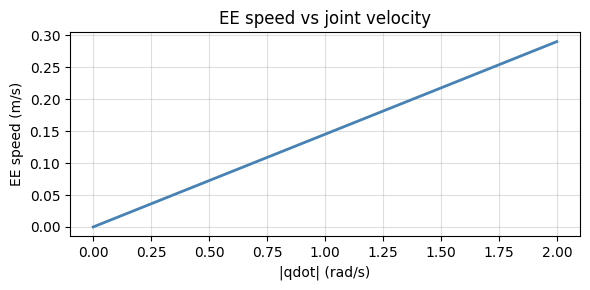

In [13]:
# EE speed vs joint velocity magnitude
scales = np.linspace(0, 2.0, 60)
qdot_d = np.array([1., 0.5, -0.5]); qdot_d /= np.linalg.norm(qdot_d)
speeds = [np.linalg.norm(ee_velocity(q, s*qdot_d)) for s in scales]

plt.figure(figsize=(6,3))
plt.plot(scales, speeds, 'steelblue', lw=2)
plt.xlabel('|qdot| (rad/s)'); plt.ylabel('EE speed (m/s)')
plt.title('EE speed vs joint velocity'); plt.grid(alpha=0.4)
plt.tight_layout(); plt.show()

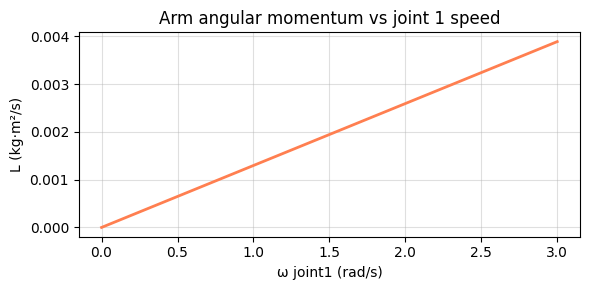

Arm inertia (joint1): 1.2963 g·m²


In [14]:
# Angular momentum of arm rotating on joint1
links = [{'mass':1.2,'r':0.035},{'mass':0.9,'r':0.030},{'mass':0.5,'r':0.025}]
I_total = sum(0.5*lp['mass']*lp['r']**2 for lp in links)
omegas  = np.linspace(0,3,60)
L = I_total * omegas

plt.figure(figsize=(6,3))
plt.plot(omegas, L, 'coral', lw=2)
plt.xlabel('ω joint1 (rad/s)'); plt.ylabel('L (kg·m²/s)')
plt.title('Arm angular momentum vs joint 1 speed'); plt.grid(alpha=0.4)
plt.tight_layout(); plt.show()
print(f'Arm inertia (joint1): {I_total*1000:.4f} g·m²')

## 7. Force sensor at end-effector

In [15]:
# Spawn a box and push into it
bp_w, bo_w = p.getBasePositionAndOrientation(loader.arm_id)

# Spawn a lightweight box the arm can actually push
col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.04, 0.04, 0.04])
vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[0.04, 0.04, 0.04],
                          rgbaColor=[0.3, 0.6, 1, 1])
obj = p.createMultiBody(0.05, col, vis,       # light mass 0.05 kg
                         [bp_w[0]+0.26, bp_w[1], bp_w[2]+0.42])
p.changeDynamics(obj, -1, lateralFriction=0.5)
env.step_n(30)

# Move arm slowly into contact
arm.move_to(np.array([0., 0.4, 0.1]), env=env, steps=150)
env.step_n(40)
arm.move_to(np.array([0., 0.55, 0.0]), env=env, steps=100)
env.step_n(40)

# Enable force/torque sensor on the joint
import pybullet as p
p.enableJointForceTorqueSensor(loader.arm_id,
                                loader.joint_map['joint3'], 1)
env.step_n(10)

readings = []
for _ in range(20):
    # Read directly from joint force-torque sensor
    jstate = p.getJointState(loader.arm_id, loader.joint_map['joint3'])
    ft     = jstate[2]            # (Fx, Fy, Fz, Mx, My, Mz)
    force_mag = np.linalg.norm(ft[:3])
    noise  = np.random.normal(0, 0.01)
    readings.append(float(force_mag + noise))
    env.step_n(5)

p.removeBody(obj)

print(f'Force readings: {[round(r,3) for r in readings]}')
print(f'Mean {np.mean(readings):.3f} N  Max {np.max(readings):.3f} N')

Force readings: [8.335, 8.35, 8.33, 8.333, 8.342, 8.338, 8.336, 8.334, 8.347, 8.332, 8.33, 8.339, 8.337, 8.35, 8.32, 8.336, 8.335, 8.321, 8.338, 8.339]
Mean 8.336 N  Max 8.350 N


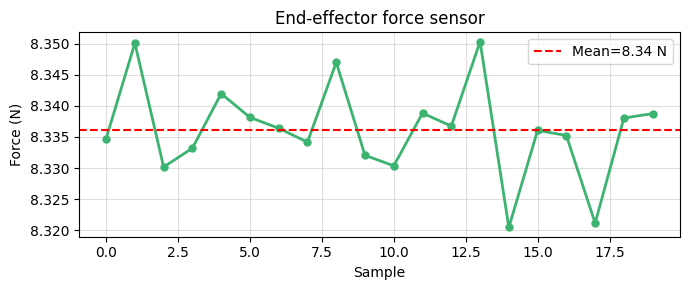

In [16]:
plt.figure(figsize=(7,3))
plt.plot(readings,'o-',color='mediumseagreen',lw=2,ms=5)
plt.axhline(np.mean(readings),color='red',ls='--',label=f'Mean={np.mean(readings):.2f} N')
plt.xlabel('Sample'); plt.ylabel('Force (N)')
plt.title('End-effector force sensor'); plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout(); plt.show()
p.removeBody(obj)

## 8. Live sinusoidal joint sweep

Running sweep (500 steps) ...


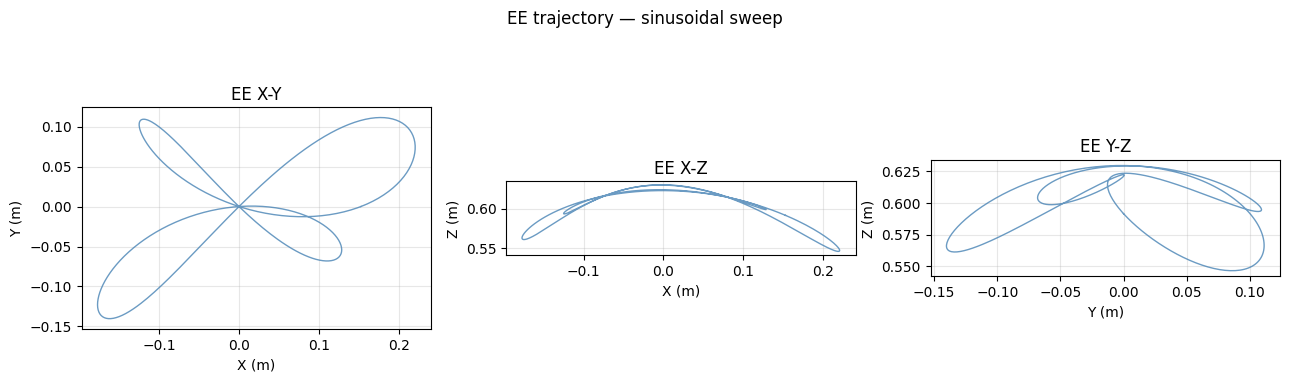

In [17]:
import numpy as np
print('Running sweep (500 steps) ...')
t_vals = np.linspace(0, 2*np.pi, 500)
ee_traj = []
for t in t_vals:
    q = np.array([0.8*np.sin(t), 0.5*np.sin(2*t+0.5), 0.4*np.cos(t)])
    loader.set_joint_positions(q)
    env.step()
    ee_traj.append(fk(q)[0].copy())

ee_traj = np.array(ee_traj)
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax,(xl,yl),(xi,yi) in zip(axes,[('X','Y'),('X','Z'),('Y','Z')],[(0,1),(0,2),(1,2)]):
    ax.plot(ee_traj[:,xi],ee_traj[:,yi],lw=1,color='steelblue',alpha=0.8)
    ax.set_xlabel(f'{xl} (m)'); ax.set_ylabel(f'{yl} (m)')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(f'EE {xl}-{yl}')
plt.suptitle('EE trajectory — sinusoidal sweep'); plt.tight_layout(); plt.show()

## 9. Cleanup

In [ ]:
viz.clear(); env.close()
print('Done.')